# Ice Recrystallization Inhibition (Two Critical Radii)

This notebook shows a minimal run of the IRI model with:
- one melting critical radius,
- one freezing critical radius,
- a stay region between them where growth velocity is zero.

## Governing equations

We evolve the particle-size distribution $f(R,t)$ and bulk concentration $c_{\mathrm{bulk}}(t)$ using:

$$
\frac{\partial f}{\partial t}+\frac{\partial}{\partial R}\left(f\,v_R\right)=0
$$

$$
\frac{d c_{\mathrm{bulk}}}{dt}=-4\pi\rho_{\mathrm{ice}}\int_0^{\infty}R^2 v_R f\,dR
$$

Define two critical radii:

$$
r_{c,\mathrm{melt}}=\frac{\alpha}{c_{\mathrm{bulk}}-c_{\mathrm{flat}}+k_mL^{-2}},
\qquad
r_{c,\mathrm{freeze}}=\frac{\alpha}{c_{\mathrm{bulk}}-c_{\mathrm{flat}}-k_fL^{-2}}
$$

Then $v_R=dR/dt$ is piecewise (three regions):

$$
v_R(R,t)=\begin{cases}
\dfrac{D}{R\rho_{\mathrm{ice}}}\left(c_{\mathrm{bulk}}-c_{\mathrm{flat}}-\dfrac{\alpha}{R}+k_mL^{-2}\right), & R<r_{c,\mathrm{melt}} \quad (\text{small-}R\ \text{branch})\\[6pt]
0, & r_{c,\mathrm{melt}}\le R\le r_{c,\mathrm{freeze}} \quad (\text{stay})\\[6pt]
\dfrac{D}{R\rho_{\mathrm{ice}}}\left(c_{\mathrm{bulk}}-c_{\mathrm{flat}}-\dfrac{\alpha}{R}-k_fL^{-2}\right), & R>r_{c,\mathrm{freeze}} \quad (\text{large-}R\ \text{branch})
\end{cases}
$$

For the stay region to be non-empty, we need $r_{c,\mathrm{melt}} < r_{c,\mathrm{freeze}}$. If these radii overlap or reverse order, the zero-velocity window shrinks or vanishes.

### Parameter definitions

$$
c_{\mathrm{flat}}=\exp\!\left(-\frac{\Delta h}{T_{\mathrm{eq}}}\frac{\Delta T}{RT}\right)\,C_{\mathrm{water}}
$$

where $C_{\mathrm{water}}=55\,\mathrm{mol/L}$ (then converted to $\mathrm{number}/\mu\mathrm{m}^3$ in code).

$$
\alpha=\frac{2\gamma}{RT}\,v_m\,c_{\mathrm{flat}}
$$

with $\gamma$ in $\mathrm{mJ}/\mathrm{m}^2$ (converted to $\mathrm{J}/\mathrm{m}^2$ in code) and $v_m$ in $\mathrm{cm}^3/\mathrm{mol}$.

$$
k_f=\frac{\alpha P_f}{2},\qquad k_m=\frac{\alpha P_m}{2}
$$

where $P_f$ and $P_m$ are effective AFP perimeters for freezing and melting, respectively.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from iri_model import run_simulation, critical_radii

In [2]:
# Parameter derivation (explicit formulas + units)

# Unit conversion: mol/L -> number/µm^3
NA = 6.02e23                         # [molecule/mol]
molL_to_num_per_um3 = NA / 1e15      # [number/µm^3]
print(f"1 mol/L = {molL_to_num_per_um3:.3e} number/µm^3")

# Physical constants and chosen conditions
delT = 5.0                            # [K], supercooling
T_eq = 273.0                          # [K]
T = 268.0                             # [K]
R_gas = 8.314                         # [J/(mol·K)]
Dh = 6000.0                           # [J/mol] molar enthalpy change for ice-water phase transition
gamma = 30.0                          # [mJ/m^2] ice-water interfacial energy
Pm = 0.005                            # [µm] perimeter of adsorbed AFP when melting
Pf = 0.01                             # [µm] perimeter of adsorbed AFP when freezing
L = 1                               # [µm] AFP separation length (characteristic length)

# If you start from water number density n_water = 33 [#/nm^3],
# convert to molar volume v_m [cm^3/mol]: v_m = N_A / n_water
n_water_nm3 = 33.0                    # [#/nm^3]
n_water_cm3 = n_water_nm3 * 1e21      # [#/cm^3] (1 cm^3 = 1e21 nm^3)
v_m = NA / n_water_cm3                # [cm^3/mol] ~ 18.2 for water
print(f"v_m from 33 #/nm^3 = {v_m:.3f} cm^3/mol")

# Diffusivity (from model assumption)
D = 1120.0                            # [µm^2/s]

# rho_ice calculation from density and molecular conversion
# rho_ice = (910 g/L) / (18 g/mol) * (6.02e23 molecule/mol) / (1e15 µm^3/L)
rho_ice = 910/18*1000*6.02*100_000    # [number/µm^3]

# Flat-interface concentration
# c_flat = exp(-(Dh/T_eq)*(delT/(R*T))) * (55 mol/L) * conversion
c_flat = np.exp(-Dh/T_eq*delT/R_gas/T) * 55.0 * molL_to_num_per_um3  # [number/µm^3]

# Gibbs-Thomson-type coefficient
# alpha = 2*gamma/(R*T) * v_m * c_flat with gamma in [mJ/m^2], v_m in [cm^3/mol], c_flat in [number/µm^3]
alpha = 2.0 * (gamma * 1e-3) / (R_gas * T) * v_m * c_flat   # [number/µm^2]

# Adsorption-length terms
invL2 = 0.0 if np.isinf(L) else 1.0 / (L**2)   # [1/µm^2], so L=inf -> invL2=0
kf = alpha * Pf / 2                              # [number/µm]
km = alpha * Pm / 2                              # [number/µm]

print(f"rho_ice = {rho_ice:.4e} [number/µm^3]")
print(f"c_flat  = {c_flat:.4e} [number/µm^3]")
print(f"alpha   = {alpha:.4e} [number/µm^2]")
print(f"kf, km  = {kf:.4e}, {km:.4e} [number/µm]")
print(f"invL2   = {invL2:.4e} [1/µm^2]")

1 mol/L = 6.020e+08 number/µm^3
v_m from 33 #/nm^3 = 18.242 cm^3/mol
rho_ice = 3.0434e+10 [number/µm^3]
c_flat  = 3.1517e+10 [number/µm^3]
alpha   = 1.5482e+07 [number/µm^2]
kf, km  = 7.7410e+04, 3.8705e+04 [number/µm]
invL2   = 1.0000e+00 [1/µm^2]


In [3]:
# Radius grid (micrometer)
R = np.linspace(0.1, 40.0, 400)

# Initial particle size distribution (Gaussian)
# f(R) unit: 1/µm^4 so that ∫f(R)dR gives number density [1/µm^3]
n = 100
V = 170**3  # [µm^3]
mean_R = 10.0
std_R = 2.0
A = n / (std_R * V * np.sqrt(2.0 * np.pi))
f_init = A * np.exp(-0.5 * ((R - mean_R) / std_R) ** 2)

# Initial concentration [number/µm^3]
c_bulk_init = (c_flat + alpha / mean_R + kf * invL2) * 1.001

# Model parameters (computed in previous cell)
params = {
    "D": D,
    "rho_ice": rho_ice,
    "c_flat": c_flat,
    "alpha": alpha,
    "k_f": kf,
    "k_m": km,
    "invL2": invL2,
    "time_unit": "ms",  # default unit is now ms
    # "flux_scheme": "gradient"
}



R_melt0, R_freeze0 = critical_radii(c_bulk_init, params)
print(f"Initial melt critical radius:   {R_melt0:.3f} µm")
print(f"Initial freeze critical radius: {R_freeze0:.3f} µm")

Initial melt critical radius:   0.467 µm
Initial freeze critical radius: 0.468 µm


In [4]:
# Run simulation (milliseconds)
t_eval = np.linspace(0.0, 3600.0 * 1000.0, 120)
sol = run_simulation(
    f_init=f_init,
    c_bulk_init=c_bulk_init,
    R=R,
    t_span=(0.0, 3600.0 * 1000.0),
    t_eval=t_eval,
    params=params,
    mode="double",  # uses two critical radii with stay region
)

f_final = sol.y[:-1, -1]
c_bulk_final = sol.y[-1, -1]
print(f"Solver success: {sol.success}")
print(f"Final c_bulk: {c_bulk_final:.4e}")

Solver success: True
Final c_bulk: 3.1518e+10


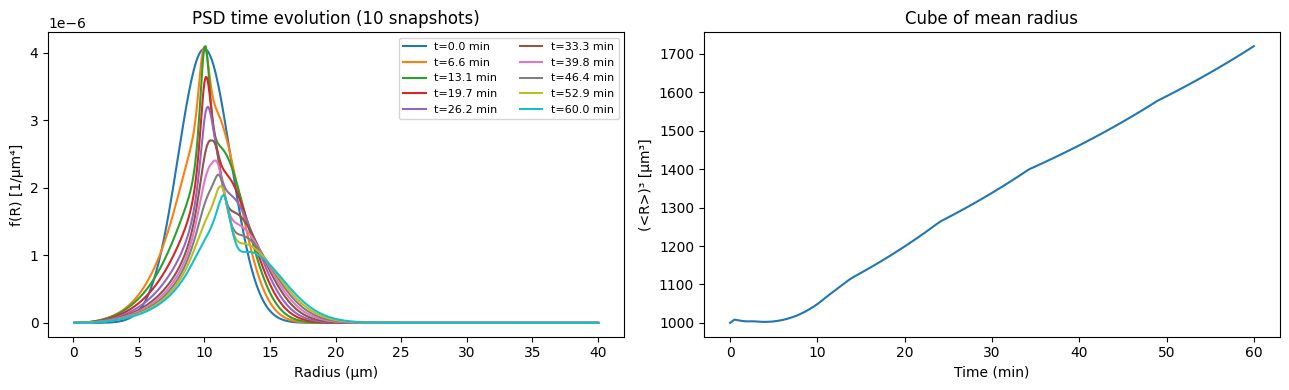

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

time_unit = str(params.get("time_unit", "ms")).lower()
if time_unit == "ms":
    time_to_min = 60000.0
elif time_unit == "s":
    time_to_min = 60.0
else:
    raise ValueError("params['time_unit'] must be 'ms' or 's'.")

# Plot ~10 PSD snapshots across time
n_snapshots = 10
snapshot_idx = np.unique(np.linspace(0, len(sol.t) - 1, n_snapshots, dtype=int))

for idx in snapshot_idx:
    t_min = sol.t[idx] / time_to_min
    axes[0].plot(R, sol.y[:-1, idx], label=f"t={t_min:.1f} min")

axes[0].set_xlabel("Radius (µm)")
axes[0].set_ylabel("f(R) [1/µm⁴]")
axes[0].set_title("PSD time evolution (10 snapshots)")
axes[0].legend(fontsize=8, ncol=2)

# Compute (<R>)^3 over time from PSD snapshots
f_list = sol.y[:-1, :].T
average_rcube = np.array([
    (np.trapezoid(R * f_t, R) / np.trapezoid(f_t, R)) ** 3
    for f_t in f_list
])

axes[1].plot(sol.t / time_to_min, average_rcube)
axes[1].set_xlabel("Time (min)")
axes[1].set_ylabel("(<R>)³ [µm³]")
axes[1].set_title("Cube of mean radius")

plt.tight_layout()
plt.show()